In [89]:
import numpy as np  
import matplotlib.pyplot as plt 

def Rotation(theta):
    R = np.array (
        [[np.cos(theta),np.sin(theta)],
         [np.sin(theta),np.cos(theta)]]
    )
    return R

[ -10.000  -9.990  -9.980  -9.970  -9.960  -9.950  -9.940  -9.930  -9.920  -9.910  -9.900  -9.890  -9.880  -9.870  -9.860  -9.850  -9.840  -9.830  -9.820  -9.810  -9.800  -9.790  -9.780  -9.770  -9.760  -9.750  -9.740  -9.730  -9.720  -9.710  -9.700  -9.690  -9.680  -9.670  -9.660  -9.650  -9.640  -9.630  -9.620  -9.610  -9.600  -9.590  -9.580  -9.570  -9.560  -9.550  -9.540  -9.530  -9.520  -9.510  -9.500  -9.490  -9.480  -9.470  -9.460  -9.450  -9.440  -9.430  -9.420  -9.410  -9.400  -9.390  -9.380  -9.370  -9.360  -9.350  -9.340  -9.330  -9.320  -9.310  -9.300  -9.290  -9.280  -9.270  -9.260  -9.250  -9.240  -9.230  -9.220  -9.210  -9.200  -9.190  -9.180  -9.170  -9.160  -9.150  -9.140  -9.130  -9.120  -9.110  -9.100  -9.090  -9.080  -9.070  -9.060  -9.050  -9.040  -9.030  -9.020  -9.010  -8.999  -8.989  -8.979  -8.969  -8.959  -8.949  -8.939  -8.929  -8.919  -8.909  -8.899  -8.889  -8.879  -8.869  -8.859  -8.849  -8.839  -8.829  -8.819  -8.809  -8.799  -8.789  -8.779  -8.769  -8.75

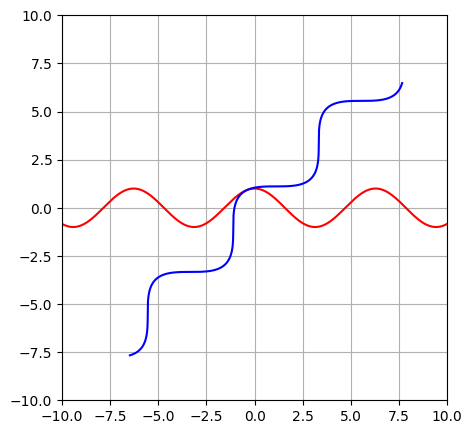

In [90]:

def Rotation(theta):
    R = np.array (
        [[np.cos(theta),-np.sin(theta)],
         [np.sin(theta),np.cos(theta)]]
    )
    return R

import numpy as np

import numpy as np

def matrix_display(arr, precision=3):
    arr = np.asarray(arr)
    
    if np.issubdtype(arr.dtype, np.integer):
        # Max width based on string length of all integers (including minus sign)
        max_width = max(len(str(val)) for row in arr for val in row)
        format_str = f"{{:>{max_width}d}}"
    else:
        # Max width based on formatted float strings
        float_strings = [f"{val:.{precision}f}" for row in arr for val in row]
        max_width = max(len(s) for s in float_strings)
        format_str = f"{{:>{max_width}.{precision}f}}"

    for row in arr:
        print("[", end=" ")
        for val in row:
            print(format_str.format(val), end=" ")
        print("]")




x = np.linspace(-10,10,2000)
y = np.cos(x)

arr = np.array([x,y])
matrix_display(arr)
plt.figure(figsize = (10,5))
plt.grid()
plt.gca().set_aspect("equal")
plt.plot(arr[0],arr[1],"r")
plt.xlim(-10,10)
plt.ylim(-10,10)

z = Rotation(np.pi/4)@(arr )
plt.plot(z[0],z[1],"b")

In [91]:
v = np.array([[3,4,5]]).T
M = np.array([
    [3,4,5],
    [9,1,2],
    [4,5,7]
])
x = (M@v)
print(x)

matrix_display(M)
print()
matrix_display(np.linalg.inv(M))


[[50]
 [41]
 [67]]
[ 3 4 5 ]
[ 9 1 2 ]
[ 4 5 7 ]

[  0.125  0.125 -0.125 ]
[  2.292 -0.042 -1.625 ]
[ -1.708 -0.042  1.375 ]


(0.20787957635076193+0j)


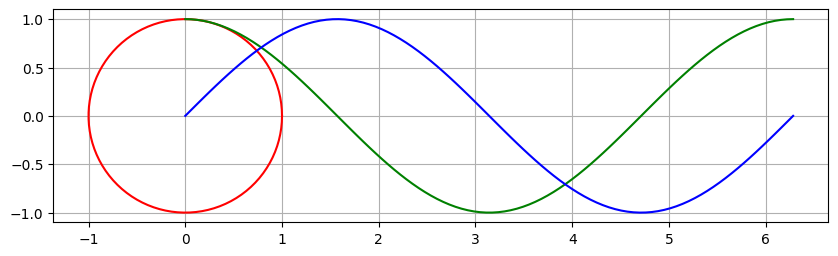

1j


In [92]:
import numpy as np
import matplotlib.pyplot as plt

i = 1j

# Some complex numbers
theta = np.linspace(0,2*np.pi,100)
z = np.e**(i*theta)

# Extract real and imaginary parts
t = theta.copy()
x = z.real
y = z.imag

print((i**i))
plt.figure(figsize=(10,5),dpi = 100)
plt.plot(x,y,'r')
plt.plot(t,x,'g')
plt.plot(t,y,'b')
plt.grid()
plt.gca().set_aspect("equal")
plt.show()

print(np.sqrt(-1+0*i))


(-5.0, 10.0)

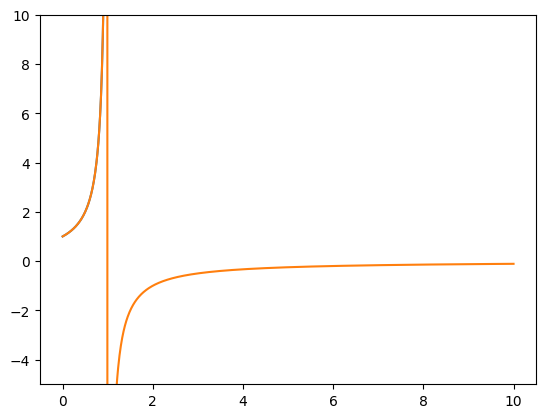

In [112]:
def dif ( fx, x):
    dydx = np.gradient(fx,x)
    return dydx

x = np.linspace(0,10,1000)
y = np.sum([x**n for n in range(50)], axis=0)
y1 = 1/(1-x)

plt.plot(x,y)
plt.plot(x,y1)
plt.ylim(-5,10)

In [ ]:

def rk4_integrate(t, f, y0, dy0):
    """
    General-purpose 4th-order Runge-Kutta integrator that computes the function value,
    its first integral, and its second integral over time.

    Parameters
    ----------
    t : ndarray
        1D array of time values (uniform spacing assumed).
    f : callable
        Function of the form f(t, y, dy) returning d²y/dt².
    y0 : ndarray
        Initial value of y.
    dy0 : ndarray
        Initial value of dy/dt.

    Returns
    -------
    y : ndarray
        Values of y(t) over time.
    dy : ndarray
        First derivative dy/dt over time.
    d2y : ndarray
        Second derivative d²y/dt² = f(t, y, dy) over time.
    """
    dt = t[1] - t[0]
    half_dt = dt / 2
    dim = len(y0)

    y = np.zeros((len(t), dim))
    dy = np.zeros((len(t), dim))
    d2y = np.zeros((len(t), dim))

    y[0] = y0
    dy[0] = dy0
    d2y[0] = f(t[0], y0, dy0)

    for i in range(len(t) - 1):
        t_i = t[i]
        y_i = y[i]
        dy_i = dy[i]

        k1_v = f(t_i, y_i, dy_i)
        k2_v = f(t_i + half_dt, y_i + dy_i * half_dt, dy_i + k1_v * half_dt)
        k3_v = f(t_i + half_dt, y_i + dy_i * half_dt, dy_i + k2_v * half_dt)
        k4_v = f(t_i + dt, y_i + dy_i * dt, dy_i + k3_v * dt)

        k1_y = dy_i
        k2_y = dy_i + k1_v * half_dt
        k3_y = dy_i + k2_v * half_dt
        k4_y = dy_i + k3_v * dt

        dy[i + 1] = dy_i + (k1_v + 2*k2_v + 2*k3_v + k4_v) * dt / 6
        y[i + 1] = y_i + (k1_y + 2*k2_y + 2*k3_y + k4_y) * dt / 6
        d2y[i + 1] = f(t[i + 1], y[i + 1], dy[i + 1])

    return y, dy, d2y


In [ ]:
Grav   = 4 * np.pi**2 
a_pert = 5.2 
M_pert = 0.000954751 
M_sun  = 1

a  = 1.8407 
e0 = 0.2003 
i0 = np.deg2rad(46.64)

L = np.sqrt(Grav*(M_sun + 1 + M_pert)*a)
G = L * np.sqrt(1-e0**2)
H = G * np.cos(i0)

def G_dot(omega):
    - 15*Grav*M_pert*a**2 / (8*a_pert**3) * (1 - (G/L)**2- (H/G)**2+(H/L)**2)*np.sin(omega)

def omega_dot()


